In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Housing.csv to Housing.csv


In [3]:
df = pd.read_csv("Housing.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (250, 4)


,area,bedrooms,bathrooms,price
0,1660,6,2,13141423
1,5991,2,2,31608379
2,4572,2,3,25121990
3,3892,6,1,22955911
4,1266,3,3,10012479


In [4]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   area       250 non-null    int64
 1   bedrooms   250 non-null    int64
 2   bathrooms  250 non-null    int64
 3   price      250 non-null    int64
dtypes: int64(4)
memory usage: 7.9 KB
None

Missing Values:
area         0
bedrooms     0
bathrooms    0
price        0
dtype: int64

Statistical Summary:
              area    bedrooms   bathrooms         price
count   250.000000  250.000000  250.000000  2.500000e+02
mean   3397.416000    3.548000    2.432000  2.005206e+07
std    1436.076352    1.721497    1.181082  7.493936e+06
min     834.000000    1.000000    1.000000  5.569203e+06
25%    2286.750000    2.000000    1.000000  1.420021e+07
50%    3482.500000    4.000000    2.000000  2.036732e+07
75%    4538.000000    5.000000    4.000000  2.550579e+07
max    5991.000000    6.000000    4.000000  3.535656e+07


In [5]:
X = df[['area', 'bedrooms', 'bathrooms']]
y = df['price']

print(X.head())

   area  bedrooms  bathrooms
0  1660         6          2
1  5991         2          2
2  4572         2          3
3  3892         6          1
4  1266         3          3


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 200
Testing Samples: 50


In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [8]:
predictions = model.predict(X_test)

print("First 10 Predictions:")
print(predictions[:10])

First 10 Predictions:
[16858146.32039947 23006409.98580435 31601874.71432072 23816404.040691
 12290777.64666368 32181317.89806825 29056209.72696645 24567687.73707065
  7176743.31852152 20857249.28771413]


In [9]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 652403.4997521832
Mean Squared Error: 636581321047.2992
Root Mean Squared Error: 797860.4646473587
R² Score: 0.9903743580367489


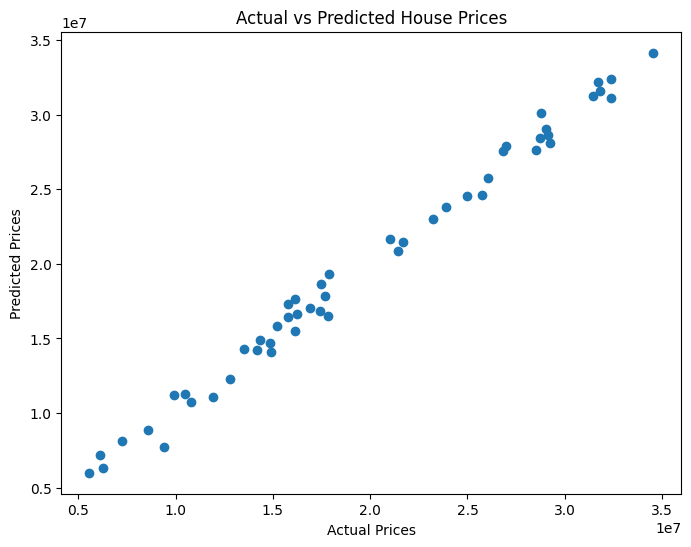

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [11]:
coefficients = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=['Coefficient']
)

print(coefficients)

             Coefficient
area         5147.551401
bedrooms   506832.993196
bathrooms  291180.305314


In [13]:
import pandas as pd

new_house = pd.DataFrame({
    'area': [2500],
    'bedrooms': [3],
    'bathrooms': [2]
})

predicted_price = model.predict(new_house)

print("Predicted House Price: ₹{:,.2f}".format(predicted_price[0]))

Predicted House Price: ₹15,042,746.33
